In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from datetime import datetime
from tqdm import tqdm
from shapely import Polygon

from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.linear_model import LinearRegression
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV
from sklearn.cluster import KMeans
from scipy.stats import skewtest, norm
from scipy.signal import find_peaks
from scipy.special import logsumexp # cuz i don't wanna always have to deal w torch tensors

import torch
import torch.nn as nn
from torch import softmax
from torch.optim.lr_scheduler import LinearLR

import sys, os, gc
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.pardir)
from coastsat import SDS_slope, SDS_tools
import pyfes

# Dataset

In [141]:
def rename_fn(name):
    if "transect" not in name: return name
    else: return name.split(" ")[-1]

def date_to_float(date_obj):
    month_py = 12
    day_py = 365.25
    hour_py = 25 * day_py
    min_py = 60 * hour_py
    sec_py = 60 * min_py
    return date_obj.year + (date_obj.month-1)/month_py + (date_obj.day-1)/day_py + date_obj.hour/hour_py + date_obj.minute/min_py + date_obj.second/sec_py

data_dir = r"C:\Users\avanever\Documents\CoastSatProject\Experiments\data\slope"
# df = pd.read_csv(os.path.join(data_dir, "raw_parksville.csv"))
df = pd.read_csv(os.path.join(data_dir, "raw_comox.csv"))
# df = pd.read_csv(os.path.join(data_dir, "raw_rose_spit_tip.csv"))
# df = pd.read_csv("raw_mini_rose_spit.csv")
df = df.rename(rename_fn, axis="columns")
df = df.drop("Unnamed: 0", axis="columns")
df["dates"] = df["dates"].apply(lambda d: datetime.strptime(d.split("+")[0], '%Y-%m-%d %H:%M:%S')) # convert string dates to datetimes
# df["dates"] = df["dates"].apply(date_to_float)
df.head()

,dates,transect_001,transect_002,transect_003,transect_004,transect_005,transect_006,transect_007,transect_008,transect_009,...,transect_077,transect_078,transect_079,transect_080,transect_081,transect_082,transect_083,transect_084,transect_085,transect_086
0,1984-04-12 18:34:47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1984-04-28 18:34:44,125.011826,132.828160,165.465518,163.477677,132.680272,NaN,NaN,NaN,NaN,...,140.552147,127.715010,105.571436,131.944515,123.797548,134.836510,131.778164,131.831049,128.637774,135.867416
2,1984-05-05 18:40:41,NaN,NaN,264.960744,NaN,NaN,62.066891,59.09608,NaN,NaN,...,57.387210,52.735558,51.700544,61.869009,54.351368,50.534550,59.471384,73.754492,64.947483,68.855571
3,1984-05-14 18:34:48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1984-05-21 18:41:11,77.516307,81.639145,76.438296,74.839377,66.161341,NaN,NaN,NaN,100.647096,...,NaN,NaN,72.653492,76.718347,77.762493,70.640457,70.265758,88.640257,88.821500,92.792497


In [142]:
n = 1

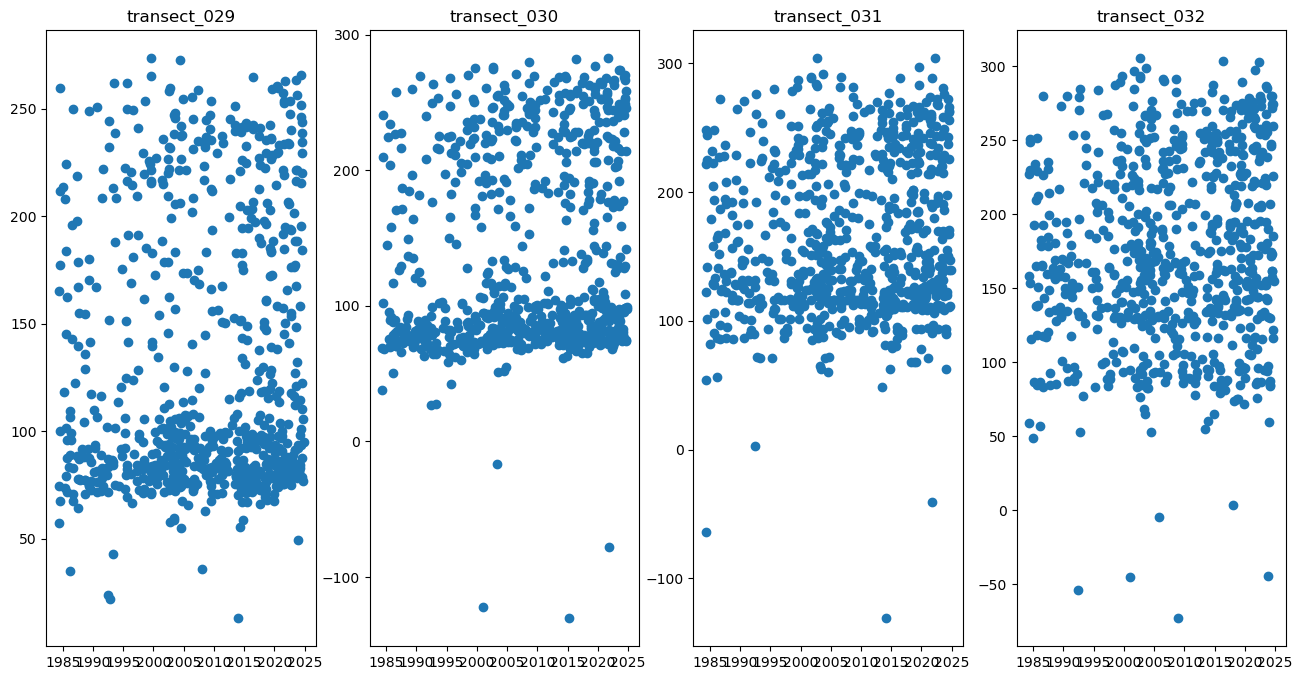

In [150]:
# transect_keys = ["transect_009", "transect_027"]
transect_keys = ["transect_" + str(i).zfill(3) for i in range(n, n+4)]

fig, axs = plt.subplots(1, len(transect_keys), figsize=(16, 8))
axs = axs.ravel()

for i, t_key in enumerate(transect_keys):
    t = df[t_key]
    nan_mask = np.isnan(t)
    dates = df["dates"][~nan_mask]
    axs[i].scatter(dates, t[~nan_mask])
    axs[i].set_title(t_key)
n += 4

# Synthetic Data

<class 'numpy.ndarray'>


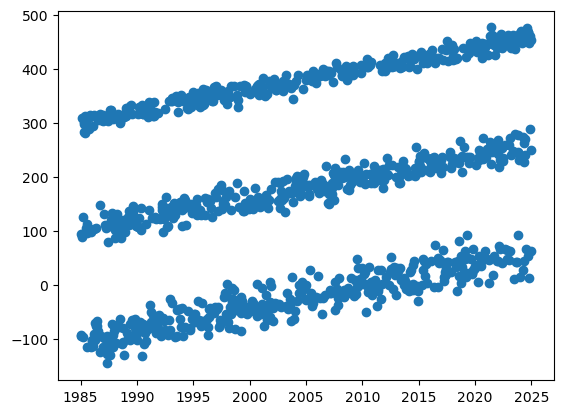

In [22]:
n_lines = 3
n_dates = len(df["dates"])
dates = np.linspace(1985, 2025, n_dates)
r_choice = np.random.choice(np.arange(n_lines), n_dates)
noise = np.random.randn(n_dates)


intercepts = [300, 100, -100]
slopes = [4, 4, 4]
sds = [10, 15, 20]

cross_distances = np.zeros(n_dates)
for i, (b, m, sd) in enumerate(zip(intercepts, slopes, sds)):
    mask = r_choice == i
    cross_distances[mask] = b + m * (dates[mask] - 1985) + noise[mask] * sd

timeseries = np.stack([dates, cross_distances], axis=1)
plt.scatter(timeseries[:,0], timeseries[:,1])
print(type(timeseries))

[Text(0.5, 1.0, 'Shoreline Position Over Time'),
 Text(0.5, 0, 'Date'),
 Text(0, 0.5, 'Cross Distance')]

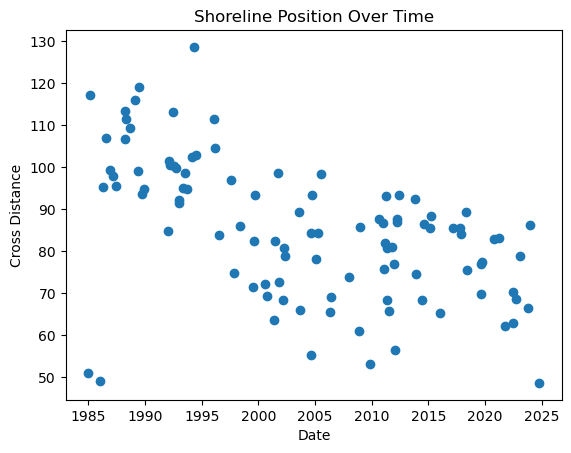

In [44]:
n_dates = len(df["dates"])
dates = np.linspace(1985, 2025, n_dates)

n_points = 100
r_choice = np.random.choice(np.arange(n_dates), n_points)
noise = np.random.randn(n_points)

b = 100
m = -0.8
sd = 12


cross_distances = b + m * (dates[r_choice] - 1985) + 8 * np.sin((dates[r_choice] - 1985)/4) + noise * sd

d = np.concatenate([dates[r_choice], [1985, 1986]])
cd = np.concatenate([cross_distances, [51, 49]])

fig, ax = plt.subplots()
ax.scatter(d, cd)
ax.set(title="Shoreline Position Over Time", xlabel="Date", ylabel="Cross Distance")

# Methods

## PCA

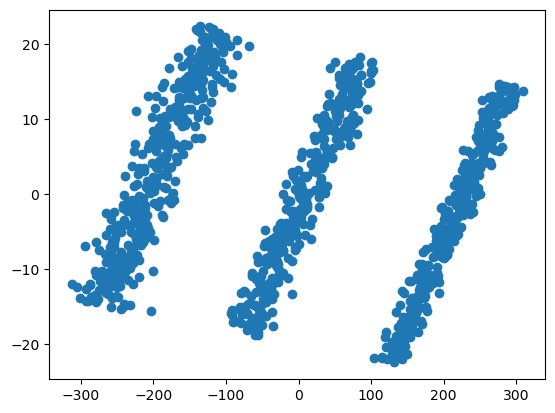

In [78]:
pca = PCA(n_components=2)
timeseries_pca = pca.fit_transform(timeseries)
plt.scatter(timeseries_pca[:,0], timeseries_pca[:,1])

## DBSCAN

In [82]:
clustering = DBSCAN(eps=10).fit(timeseries)
clustering.labels_

array([0, 1, 0, ..., 1, 2, 0], shape=(1041,))

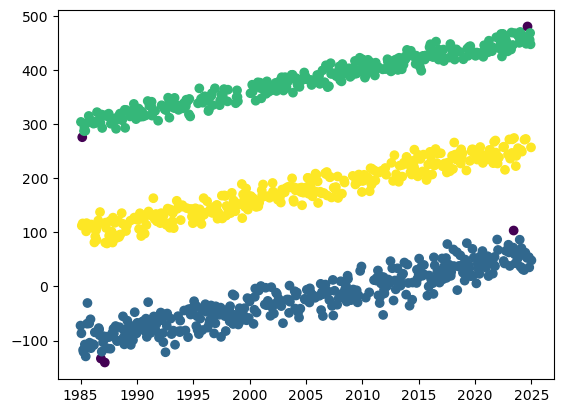

In [ ]:
plt.scatter(timeseries[:,0], timeseries[:,1], c=clustering.labels_)

In [140]:
t_key = "transect_032"
nan_mask = np.isnan(df[t_key])
timeseries = np.stack([df["dates"][~nan_mask], df[t_key][~nan_mask]], axis=1)

clustering = DBSCAN(eps=10).fit(timeseries)
clustering.labels_
plt.scatter(timeseries[:,0], timeseries[:,1], c=clustering.labels_)

DTypePromotionError: The DType <class 'numpy.dtypes.DateTime64DType'> could not be promoted by <class 'numpy.dtypes.Float64DType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.DateTime64DType'>, <class 'numpy.dtypes.Float64DType'>)

## Multiple Lines Thing

In [17]:
a = np.array([0.001, 1, 2, 10, 112])
a = torch.Tensor(a)

softmin1 = -torch.logsumexp(-a, dim=0)

rho = 10
softmin2 = -(1 / rho) * torch.logsumexp(-rho * a, dim=0)

rho = 10
softmin3 = torch.sum(a * softmax(-rho * a, dim=0))

print(f"{softmin1 = }")
print(f"{softmin2 = }")
print(f"{softmin3 = }")

softmin1 = tensor(-0.4070)
softmin2 = tensor(0.0010)
softmin3 = tensor(0.0010)


In [ ]:
class MultiLineLoss(nn.Module):
    def __init__(self, rho, mode):
        super(MultiLineLoss, self).__init__()
        self.rho = rho
        self.mode = mode

    def forward(self, input, target):
        error = (input - target) ** 2
        if self.mode == 1: softmin = -(1 / self.rho) * torch.logsumexp(-self.rho * error, dim=1)
        if self.mode == 2: softmin = torch.sum(error * softmax(- rho * error, dim=1))
        loss = torch.mean(softmin)
        return loss
    

class Model(nn.Module):
    def __init__(self, n_lines, y_min, y_max):
        super(Model, self).__init__()
        self.n_lines = n_lines
        self.bias = torch.empty(1, n_lines).requires_grad_()
        self.shared_slope = nn.Parameter(torch.tensor([1.0])).requires_grad_()
        # self.shared_slope = torch.empty(1, n_lines).requires_grad_()

        # initialize weights with reasonable values
        with torch.no_grad():
            self.shared_slope[0] = 0
            # self.shared_slope[:] = 0
            if n_lines >= 2:
                self.bias[0,0] = y_min
                self.bias[0,1] = y_max
            if n_lines == 3:
                self.bias[0,2] = (y_min + y_max) / 2
    
    def forward(self, x):
        models = torch.cat([self.shared_slope.expand(1, self.n_lines), self.bias], dim=0)
        return torch.mm(x, models)
    
    def fit(self, X, y, loss_fn, n_epochs, lr):
        self.batch_size = 256

        # prepare data
        train_ds = torch.utils.data.TensorDataset(X, y)
        dataloader = torch.utils.data.DataLoader(
            train_ds,
            batch_size=self.batch_size,
            shuffle=True,
        )

        # Model initialization
        optimizer = torch.optim.Adam([self.bias, self.shared_slope], lr=lr)
        lr_sched = LinearLR(optimizer, start_factor=1.0, end_factor=0.01, total_iters=len(dataloader) * n_epochs // 2)

        self.train()
        losses = []
        min_loss = torch.inf
        weights = []
        lrs = []
        for _ in tqdm(range(n_epochs)):

            for X, y in dataloader:
                y_hat = self(X)

                # compute losses
                loss = loss_fn(y_hat, y)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                lr_sched.step()


            losses.append(loss.item())
            lrs.append(lr_sched.get_last_lr())
            
            # add best model so far
            if loss < min_loss:
                min_loss = loss
                
                models = torch.cat([self.shared_slope.expand(1, self.n_lines), self.bias], dim=0)
                weights.append(models.detach().clone())
            else:
                weights.append(weights[-1])

        return losses, weights, lrs

### Synthetic Data

In [23]:
# preprocessing
ts_tensor = torch.Tensor(timeseries)

ts_x = ts_tensor[:,0].reshape(-1,1) - 1985
ts_x = torch.concatenate([ts_x, torch.ones(len(ts_x), 1)], dim=1)

ts_y = ts_tensor[:,1].reshape(-1,1)
ts_y = (ts_y - torch.mean(ts_y)) / torch.std(ts_y)

100%|██████████| 400/400 [00:05<00:00, 67.13it/s]


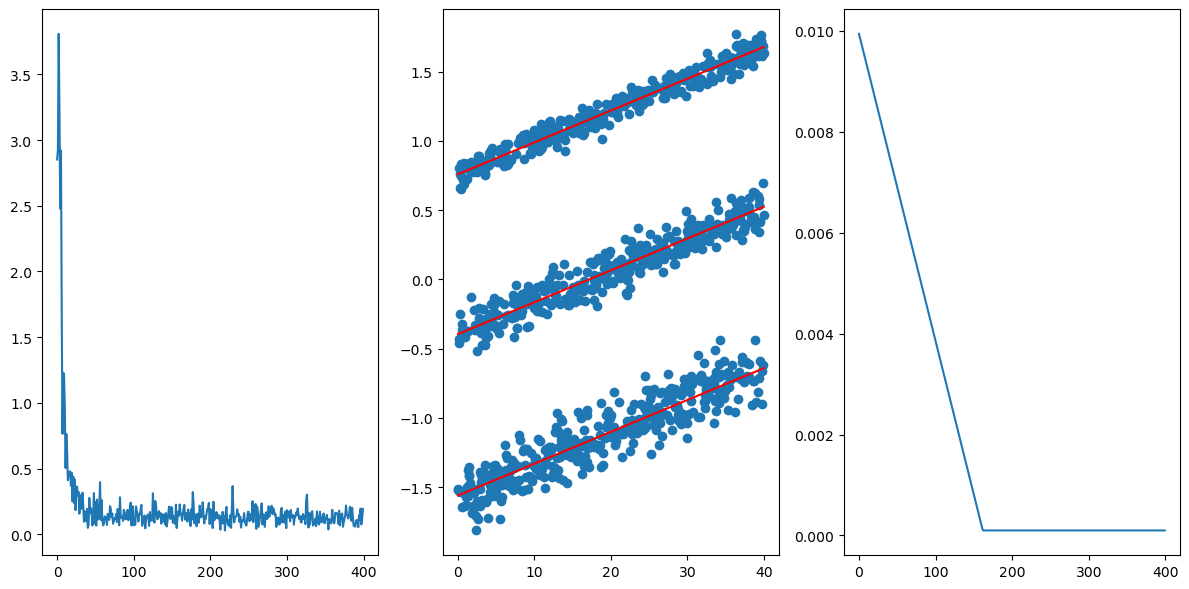

In [25]:
loss_fn = MultiLineLoss(10)
model = Model(3, ts_y.min().item(), ts_y.max().item())
loss, weights, lrs = model.fit(ts_x, ts_y, loss_fn, 400, 1e-2)

fig, axs = plt.subplots(1, 3, figsize=(12, 6), tight_layout=True)
axs[0].plot(loss)
axs[1].scatter(ts_x[:,0], ts_y[:,0])
with torch.no_grad():
    y_hat = torch.mm(ts_x, weights[-1])
    axs[1].plot(ts_x[:,0], y_hat, c="red");
axs[2].plot(lrs)


In [26]:
all_outputs = torch.stack([torch.mm(ts_x, weights[frame]) for frame in range(len(weights))])
y_min = torch.min(ts_y).item()
y_max = torch.max(ts_y).item()

fig, ax = plt.subplots(1, 2)
scat = ax[0].scatter(ts_x[:,0], ts_y[:,0])
lines = ax[0].plot(ts_x[:,0], all_outputs[0], c="red")
ax[0].set_ylim(y_min, y_max)

ax[1].plot(loss)
vline = ax[1].axvline(0, c="red")

def update(frame):
    output = all_outputs[frame]
    for i in range(all_outputs.shape[-1]):
        lines[i].set_data(ts_x[:,0], output[:,i])
    vline.set_xdata([frame, frame])

    return lines

ani = animation.FuncAnimation(fig=fig, func=update, frames=len(weights), interval=60)
# ani = animation.FuncAnimation(fig=fig, func=update, frames=50, interval=30)
ani.save(filename="ex.gif", writer="pillow")
plt.close(fig)

### Real Data

In [18]:
def prepro_real_data(t_key, df):
    nan_mask = np.isnan(df[t_key])
    timeseries = np.stack([df["dates"][~nan_mask], df[t_key][~nan_mask]], axis=1)
    ts_tensor = torch.Tensor(timeseries)

    ts_x = ts_tensor[:,0].reshape(-1,1) - ts_tensor[0,0] - (ts_tensor[-1,0] - ts_tensor[0,0]) / 2
    ts_x = torch.concatenate([ts_x, torch.ones(len(ts_x), 1)], dim=1)

    ts_y = ts_tensor[:,1].reshape(-1,1)
    ts_y = (ts_y - torch.mean(ts_y)) / torch.std(ts_y)

    return ts_x, ts_y

In [21]:
idx = 19
t_key = "transect_" + str(idx).zfill(3)
ts_x, ts_y = prepro_real_data(t_key, df)

loss_fn = MultiLineLoss(5, mode=2)
model = Model(2, ts_y.min().item(), ts_y.max().item())
loss, weights, lrs = model.fit(ts_x, ts_y, loss_fn, 750, 1e-2)

fig, axs = plt.subplots(1, 2, figsize=(12, 6), tight_layout=True)
axs[0].plot(loss)
axs[1].scatter(ts_x[:,0], ts_y[:,0])
with torch.no_grad():
    y_hat = model(ts_x)
    axs[1].plot(ts_x[:,0], y_hat, c="red");
print(loss[-1])

  0%|          | 0/750 [00:00<?, ?it/s]


NameError: name 'rho' is not defined

#### Differentiating Cases

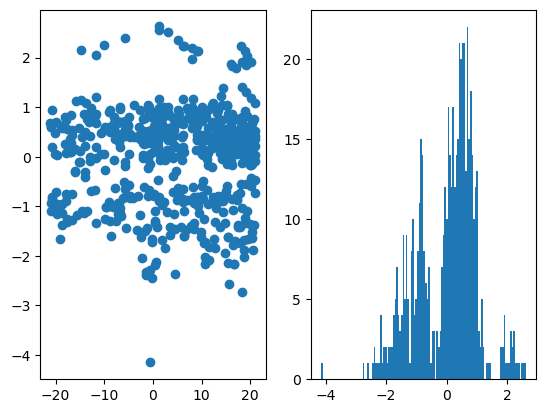

In [29]:
""" Counting peaks"""
def shearx_mat(shear_x):
    m = torch.eye(2)
    m[1,0] = shear_x
    return m

shear_mat = shearx_mat(-weights[-1][0,0]) # negated learned slope
data = torch.stack([ts_x[:,0], ts_y[:,0]])
transformed = torch.mm(shear_mat, data)

fig, axs = plt.subplots(1, 2)
axs[0].scatter(transformed[0,:], transformed[1,:])
axs[1].hist(transformed[1,:], bins=128);

# find_peaks(transformed[1,:], height=2, width=2)

In [103]:
def gmm_bic_score(estimator, X):
    return -estimator.bic(X)

param_grid = {"n_components": range(1, 3)}
grid_search = GridSearchCV(
    GaussianMixture(), param_grid=param_grid, scoring=gmm_bic_score
)
grid_search.fit(transformed[1,:].reshape(-1, 1).numpy())

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GaussianMixture()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_components': range(1, 3)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",<function gmm...001F159F02700>
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold a

24.0


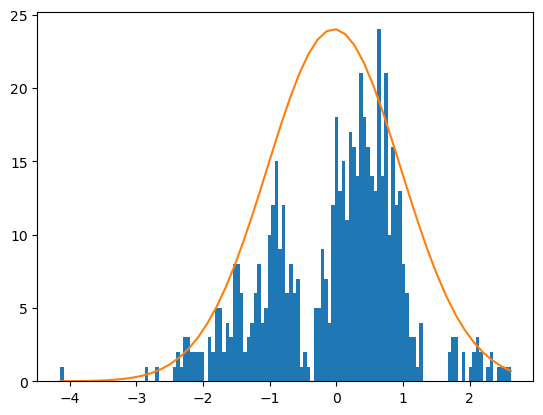

In [ ]:
mean = grid_search.best_estimator_.means_[0,0]
var = grid_search.best_estimator_.covariances_[0,0,0]

x = np.linspace(min(transformed[1,:]), max(transformed[1,:]))
y = norm.pdf(x, loc=mean, scale=var)

fig, ax = plt.subplots()
n, _, _= ax.hist(transformed[1,:], bins=128);
ax.plot(x, y * max(n) / max(y))

(0, 2): 6.995390378072841e-10
(2, 1): 2.3486331883759703e-06


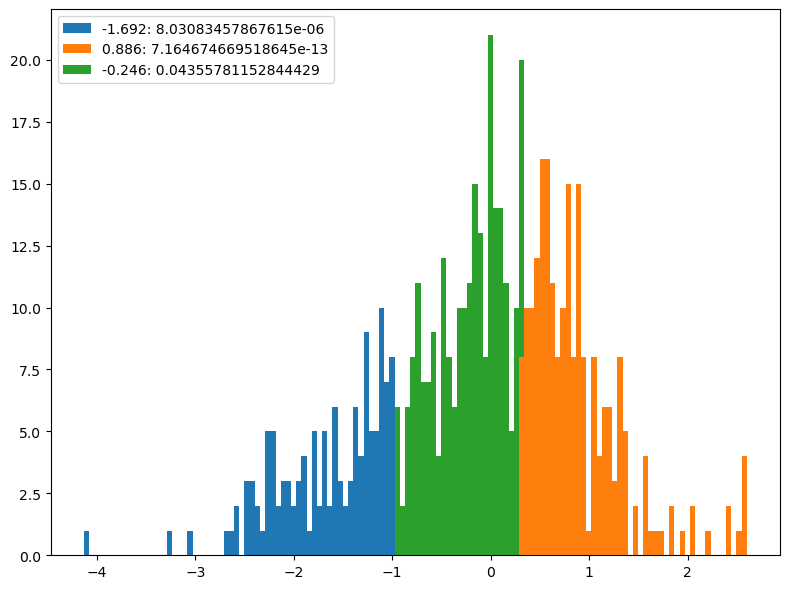

In [31]:
""" Looking at residual distribution for each line"""
w = weights[-1]
output = torch.mm(ts_x, w)
residual = (ts_y - output).numpy()
min_idx = np.argmin(np.abs(residual), axis=1)

def get_dist(res, min_idx, dist_num):
    mask = min_idx == dist_num
    return np.array(res[mask, dist_num])
dists = [get_dist(residual, min_idx, i) + w[1,i].item() for i in range(w.shape[1])]
statistics = [skewtest(dists[i]) for i in range(w.shape[1])]

fig, ax = plt.subplots(1, 1, figsize=(8, 6), tight_layout=True)
labels = [f"{w[1,i].item():.3f}: {statistics[i].pvalue}" for i in range(w.shape[1])]
ax.hist(dists, stacked=True, bins=128, label=labels)
ax.legend();

""" Does merging adjacent distributions make either more symmetric"""
# Doesn't work for transect 019
sorted_idx = np.argsort(w[1])
print(f"{sorted_idx[0].item(), sorted_idx[1].item()}: {skewtest(np.concatenate([dists[sorted_idx[0]], dists[sorted_idx[1]]])).pvalue}")
if len(sorted_idx) == 3:
    print(f"{sorted_idx[1].item(), sorted_idx[2].item()}: {skewtest(np.concatenate([dists[sorted_idx[1]], dists[sorted_idx[2]]])).pvalue}")

In [883]:
""" Comparing how far lines are apart is an inconsistent statistic """
w = weights[-1]
intercepts = w[1]

min_dist = np.inf
max_dist = 0
for i in range(len(intercepts)):
    for j in range(i + 1, len(intercepts)):
        dist = abs(intercepts[i] - intercepts[j])
        if dist < min_dist: min_dist = dist
        if dist > max_dist: max_dist = dist
print(min_dist, max_dist, min_dist / max_dist)

tensor(0.9057) tensor(2.4278) tensor(0.3730)


In [ ]:
""" Increasing # lines improves loss, even if lines are identical """
test_w = torch.Tensor([
    [0, 0, 0, 0, 0, 0, 0, 0],
    [ 1.40, -0.52, -0.52, -0.52, -0.52, -0.52, -0.52, -0.52]
])

output = torch.mm(ts_x, test_w)
loss = loss_fn(output, ts_y)
loss

tensor(333.5197)

#### Comparing Loss Functions

In [49]:
def evaluate(X, y, weights):
    y_hat = torch.mm(X, weights)
    residuals = y_hat - y
    residuals, _ = torch.min(residuals, dim=1)
    return torch.mean(residuals ** 2)

transect_idx = range(1, 40)

loss1 = []
loss2 = []
for idx in transect_idx:
    t_key = "transect_" + str(idx).zfill(3)
    ts_x, ts_y = prepro_real_data(t_key, df)

    loss_fn = MultiLineLoss(5, mode=1)
    model = Model(3, ts_y.min().item(), ts_y.max().item())
    loss, weights, lrs = model.fit(ts_x, ts_y, loss_fn, 750, 1e-2)
    loss1.append(evaluate(ts_x, ts_y, weights[-1]))
    
    loss_fn = MultiLineLoss(5, mode=2)
    model = Model(3, ts_y.min().item(), ts_y.max().item())
    loss, weights, lrs = model.fit(ts_x, ts_y, loss_fn, 750, 1e-2)
    loss2.append(evaluate(ts_x, ts_y, weights[-1]))

100%|██████████| 750/750 [00:13<00:00, 57.16it/s]


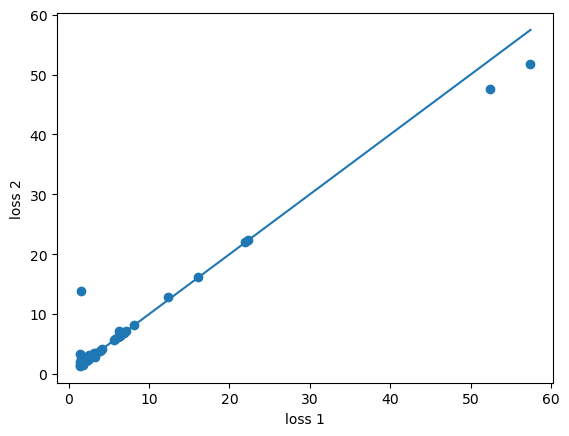

In [50]:
plt.scatter(loss1, loss2)
plt.xlabel("loss 1")
plt.ylabel("loss 2")

minimum = min(min(loss1), min(loss2))
maximum = max(max(loss1), max(loss2))
plt.plot([minimum, maximum], [minimum, maximum])

## Linear Regression

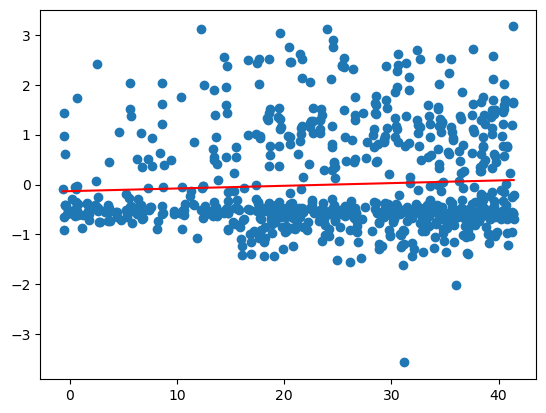

In [710]:
idx = 32
t_key = "transect_" + str(idx).zfill(3)
ts_x, ts_y = prepro_real_data(t_key, df)
reg = LinearRegression().fit(ts_x, ts_y[:,0].reshape(-1, 1))
output = reg.predict(ts_x.numpy())

fig, ax = plt.subplots()
ax.scatter(ts_x[:,0], ts_y[:,0])
ax.plot(ts_x[:,0], output, c="red");

## Tides

In [151]:
fes_config = r"C:\Users\avanever\Documents\CoastSatProject\fes2022\fes2022.yaml"
# aoi_kml = r"C:\Users\avanever\Documents\CoastSatProject\Sites\parksville\inputs\parksville_aoi.kml"
aoi_kml = r"C:\Users\avanever\Documents\CoastSatProject\Input Data\AOI KML\comox1.kml"
handlers = pyfes.load_config(fes_config)
ocean_tide = handlers["tide"]
load_tide = handlers["radial"]

polygon = SDS_tools.polygon_from_kml(aoi_kml)
polygon = SDS_tools.smallest_rectangle(polygon)
aoi_geom = Polygon(polygon[0])
centroid = SDS_tools.select_valid_centroid(aoi_geom, ocean_tide, load_tide)

dates_ts, tides_ts = SDS_slope.compute_tide(centroid, df["dates"], 900, ocean_tide, load_tide)

dates_sat = df["dates"]
tides_sat = np.asarray(
    SDS_slope.compute_tide_dates(centroid, dates_sat, ocean_tide, load_tide),
    dtype=float,
)

del ocean_tide, load_tide
gc.collect()

[Centroid Selection] Starting candidate evaluation...
Tested point: [235.0842, 49.6661] --> Ocean Flags: [2]
Tested point: [235.0842, 49.6574] --> Ocean Flags: [2]
Tested point: [235.0842, 49.6749] --> Ocean Flags: [1]
Tested point: [235.0616, 49.6661] --> Ocean Flags: [2]
Tested point: [235.1068, 49.6661] --> Ocean Flags: [3]
[Centroid Selection] No ideal candidate found (flag 4). Starting refinement sweep...
Refinement test at radius 0.03: [235.1368, 49.6661] --> Ocean Flags: [4]
[Centroid] Refined to: [235.136795, 49.666132] with ocean flags [4]
Flags (Ocean): [4]
Flags (Load): [4]


101468

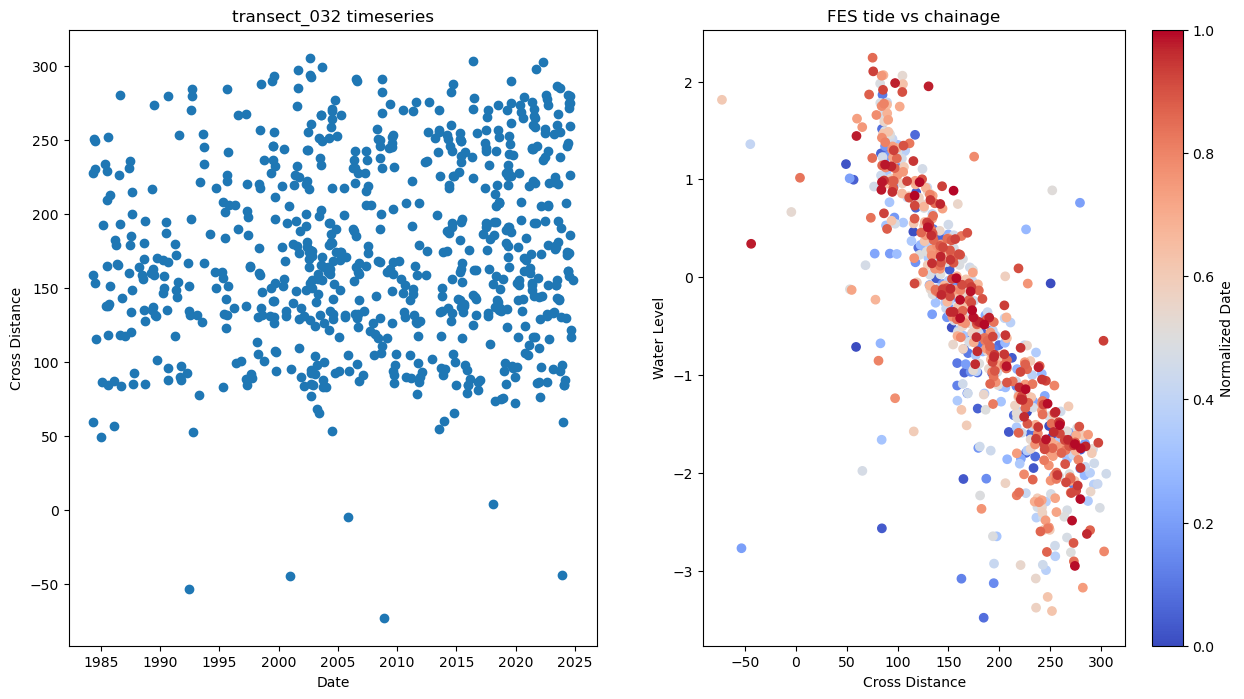

In [152]:
idx = 32
t_key = "transect_" + str(idx).zfill(3)
chainage = df[t_key]
nan_mask = ~np.isnan(chainage)

fig, ax = plt.subplots(1, 2, figsize=(15, 8))
ax = ax.ravel()
ax[0].scatter(dates_sat[nan_mask], chainage[nan_mask])
ax[0].set(title=f"{t_key} timeseries", xlabel="Date", ylabel="Cross Distance")

min_date, max_date = np.min(dates_sat[nan_mask]), (np.max(dates_sat[nan_mask]))
c = (dates_sat[nan_mask] - min_date) / (max_date - min_date)
sc = ax[1].scatter(chainage[nan_mask], tides_sat[nan_mask], c=c, cmap="coolwarm")
ax[1].set(title="FES tide vs chainage", xlabel="Cross Distance", ylabel="Water Level")
fig.colorbar(sc, ax=ax[1], label="Normalized Date")

In [12]:
X = np.stack([chainage[nan_mask], tides_sat[nan_mask]]).T
kmeans = KMeans(n_clusters=2).fit(X)

[Text(0.5, 1.0, 'transect_032 timeseries')]

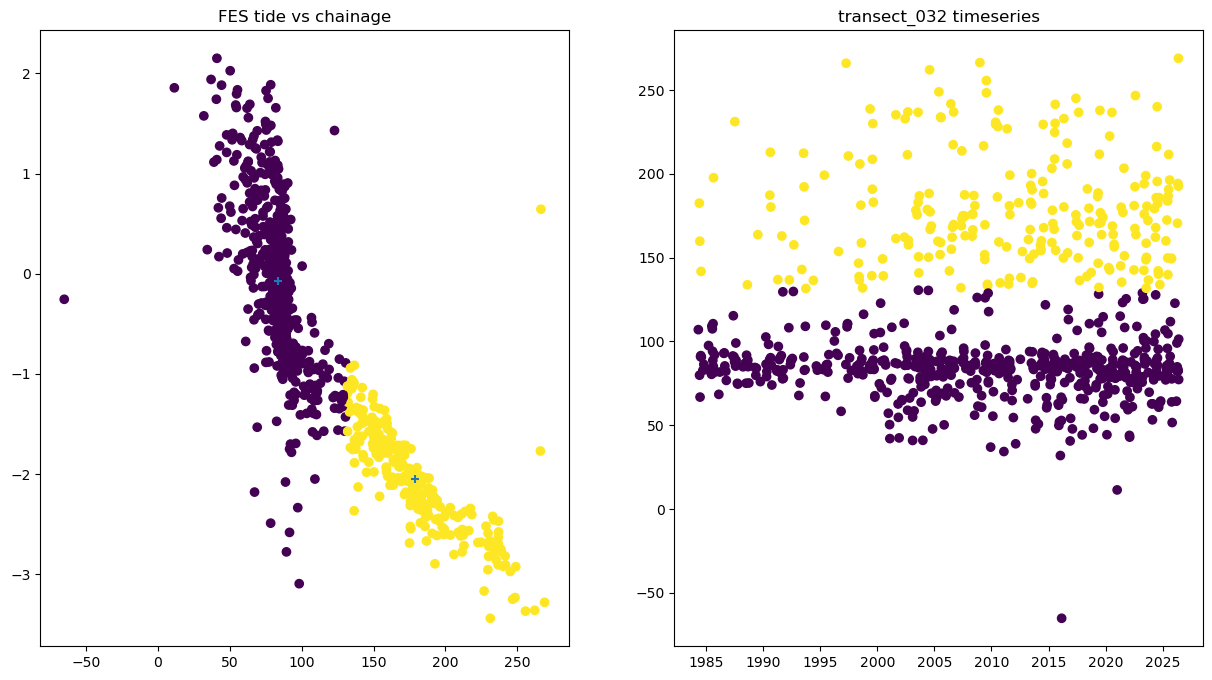

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(15, 8))

ax[0].scatter(chainage[nan_mask], tides_sat[nan_mask], c=kmeans.labels_)
ax[0].scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], marker="+")
ax[0].set(title="FES tide vs chainage")

ax[1].scatter(dates_sat[nan_mask], chainage[nan_mask], c=kmeans.labels_)
ax[1].set(title=f"{t_key} timeseries")

## Lidar Profile

In [6]:
idx = 32
profile_csv = pd.read_csv(os.path.join(data_dir, f"Qualicum_LIDAR_{str(idx).zfill(3)}.csv"))
chainage = df[t_key]
nan_mask = ~np.isnan(chainage)

profile_csv.head()

,Dist,Elev
0,0.000000,4.98
1,0.527440,4.95
2,1.054881,4.95
3,1.582321,4.93
4,2.109761,4.89


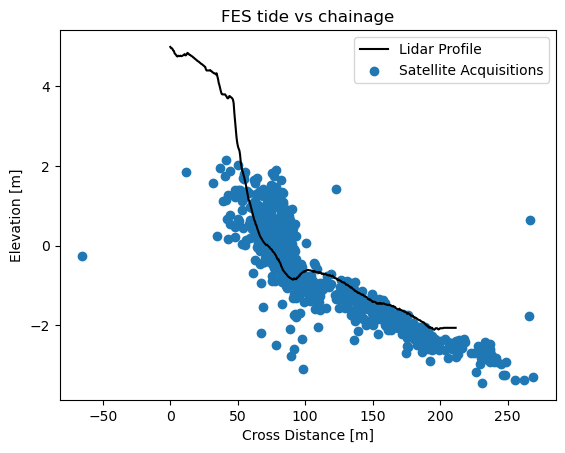

In [8]:
fig, ax = plt.subplots()
ax.plot(profile_csv["Dist"], profile_csv["Elev"], c="black", label="Lidar Profile")
ax.scatter(chainage[nan_mask], tides_sat[nan_mask], label="Satellite Acquisitions")
ax.set(title="FES tide vs chainage", xlabel="Cross Distance [m]", ylabel="Elevation [m]")
ax.legend()

## Linear Splines

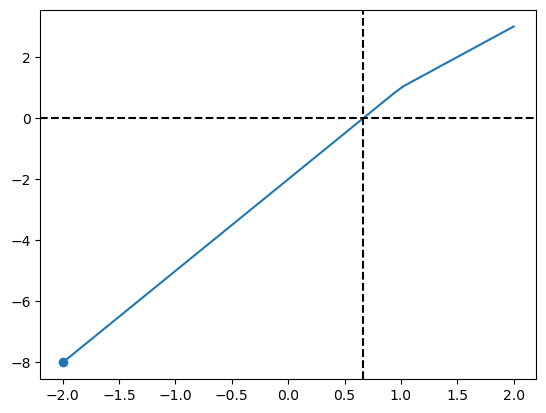

In [113]:
def linear_splines(x, m1, m2, x0, y0):
    indicator = x < x0
    return indicator * (y0 - m1 * (x0 - x)) + ~indicator * (y0 + m2 * (x - x0))

def linear_spline_correction(x, y, m1, m2, y0):

    # have to traverse line x starts on first
    m1_prime, m2_prime = (m1, m2) if y < y0 else (m2, m1)

    if (y < 0) == (y0 < 0):
        correction = (y0 - y) / m1_prime - y0 / m2_prime
    else:
        correction = -y / m1_prime

    return x + correction

m1, m2, x0, y0 = 3, 2, 1, 1
x = np.linspace(-2, 2)
y = linear_splines(x, m1, m2, x0, y0)

new_x, new_y = -2, -8
corrected = linear_spline_correction(new_x, new_y, m1, m2, y0)

fig, ax = plt.subplots()
ax.plot(x, y)
# plt.plot([new_x, corrected], [new_y, 0])
ax.scatter(new_x, new_y)
ax.axhline(0, c="black", linestyle="--")
ax.axvline(corrected, c="black", linestyle="--")

[Text(0.5, 1.0, 'tide corrected timeseries'),
 Text(0.5, 0, 'Date'),
 Text(0, 0.5, 'Cross Distance')]

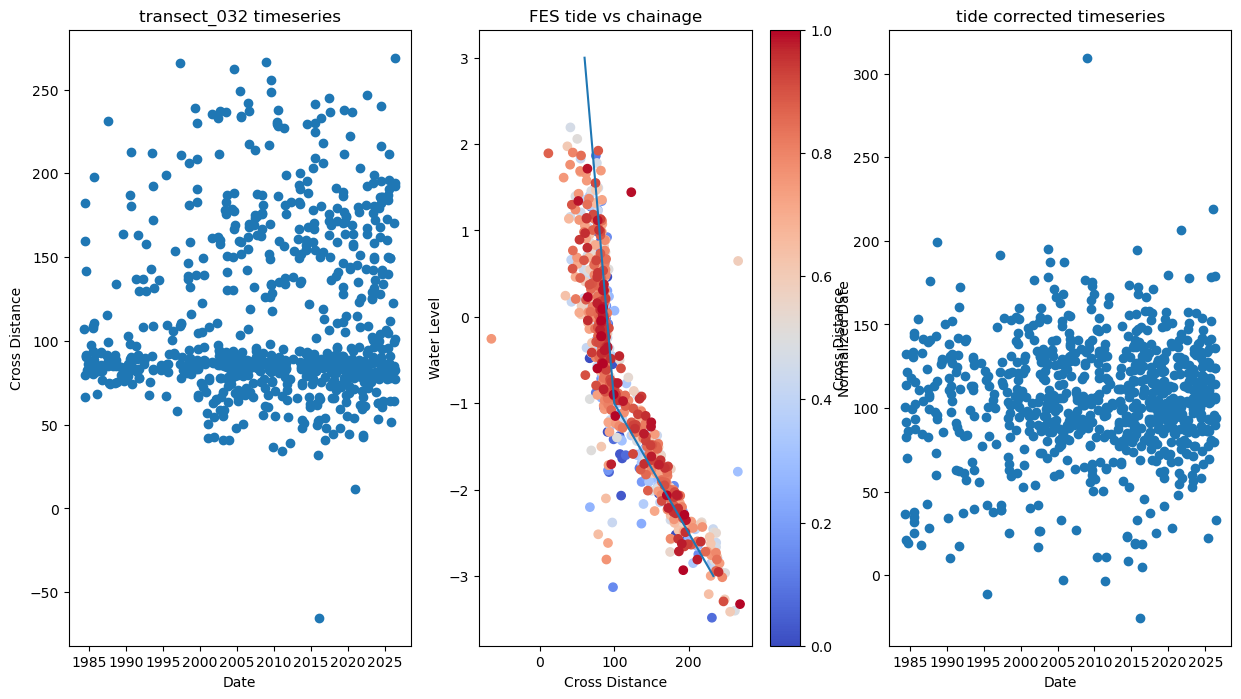

In [139]:
idx = 32
t_key = "transect_" + str(idx).zfill(3)
chainage = df[t_key]
nan_mask = ~np.isnan(chainage)# & (chainage < 100) & (chainage > 75)

fig, ax = plt.subplots(1, 3, figsize=(15, 8))
ax = ax.ravel()
ax[0].scatter(dates_sat[nan_mask], chainage[nan_mask])
ax[0].set(title=f"{t_key} timeseries", xlabel="Date", ylabel="Cross Distance")

min_date, max_date = np.min(dates_sat[nan_mask]), (np.max(dates_sat[nan_mask]))
c = (dates_sat[nan_mask] - min_date) / (max_date - min_date)
sc = ax[1].scatter(chainage[nan_mask], tides_sat[nan_mask], c=c, cmap="coolwarm")
ax[1].set(title="FES tide vs chainage", xlabel="Cross Distance", ylabel="Water Level")
fig.colorbar(sc, ax=ax[1], label="Normalized Date")

m1, m2, x0, y0 = -0.1, -0.015, 100, -1
# m1, m2, x0, y0 = 10, 10, 100, -1
x = np.linspace(50, 250, num=1000)
y = linear_splines(x, m1, m2, x0, y0)
spline_mask = (y < 3) & (y > -3)
ax[1].plot(x[spline_mask], y[spline_mask])

tidally_corrected = [linear_spline_correction(x_new, y_new, m1, m2, y0) for (x_new, y_new) in zip(chainage[nan_mask], tides_sat[nan_mask])]
ax[2].scatter(dates_sat[nan_mask], tidally_corrected)
ax[2].set(title=f"tide corrected timeseries", xlabel="Date", ylabel="Cross Distance")

In [343]:
fig, ax = plt.subplots()
sc = ax.scatter(chainage[nan_mask][:50], tides_sat[nan_mask][:50])
title = "FES tide vs chainage"
ax.set(title=title, ylim=(-4, 2.5), xlim=(-75, 275))

def update(frame):
    s, e = frame * 50, (frame + 1) * 50
    e = min(len(chainage), e)
    points = np.stack([chainage[nan_mask][s:e], tides_sat[nan_mask][s:e]], axis=1)
    sc.set_offsets(points)
    ax.set(title=title + ". frame: " + str(frame))
    return sc

ani = animation.FuncAnimation(fig=fig, func=update, frames=(len(chainage[nan_mask]) // 100) + 1, interval=200)
ani.save(filename="tide_vs_chainage_over_time.gif", writer="pillow")
plt.close(fig)


In [151]:
class LinearSplinesNN(nn.Module):
    def __init__(self, n_hidden_layers, width):
        super(LinearSplinesNN, self).__init__()
        self.n_hidden_layers = n_hidden_layers
        self.width = width

        layers = []
        layers.append(nn.Linear(1, self.width))
        layers.append(nn.ReLU())
        for i in range(self.n_hidden_layers):
            layers.append(nn.Linear(self.width, self.width))
            layers.append(nn.ReLU())
        layers.append(nn.Linear(self.width, 4))

        self.model = nn.Sequential(*layers)
    
    def forward(self, x):
        times = x[:,0].reshape(-1, 1)
        distance = x[:,1].reshape(-1, 1)
        params = self.model(times).T
        return self.linear_splines(distance, *params)
    
    def linear_splines(self, x, m1, m2, x0, y0):
        indicator = x < x0
        return indicator * (y0 - m1 * (x0 - x)) + ~indicator * (y0 + m2 * (x - x0))

    def fit(self, X, y, loss_fn, n_epochs, lr):
        self.batch_size = 128

        # prepare data
        train_ds = torch.utils.data.TensorDataset(X, y)
        dataloader = torch.utils.data.DataLoader(
            train_ds,
            batch_size=self.batch_size,
            shuffle=True,
        )

        # Model initialization
        optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)
        lr_sched = LinearLR(optimizer, start_factor=1.0, end_factor=0.001, total_iters=len(dataloader) * n_epochs // 2)

        self.train()
        losses = []
        lrs = []
        for _ in tqdm(range(n_epochs)):

            for X, y in dataloader:
                y_hat = self(X)

                # compute losses
                loss = loss_fn(y_hat, y)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                lr_sched.step()

            losses.append(loss.item())
            lrs.append(lr_sched.get_last_lr())

        return losses, lrs

In [215]:
def dt_to_jd(dt):
    a = (14 - dt.month) // 12
    y = dt.year + 4800 - a
    m = dt.month + 12 * a - 3
    jdn = dt.day + ((153 * m + 2) // 5) + 365 * y + y // 4 - y // 100 + y // 400 - 32045
    return jdn

def standardize(arr):
    return ((arr - min(arr)) / (max(arr) - min(arr))) * 2 - 1

In [216]:
idx = 32

t_key = "transect_" + str(idx).zfill(3)
chainage = df[t_key]
nan_mask = ~np.isnan(chainage)
chainage = standardize(chainage[nan_mask])
jds = df["dates"].apply(dt_to_jd)
dates = standardize(jds[nan_mask])
tides = standardize(tides_sat[nan_mask])

X = torch.Tensor(np.stack([dates, chainage])).T
y = torch.Tensor(tides.reshape(-1, 1))

100%|██████████| 100/100 [00:03<00:00, 33.28it/s]


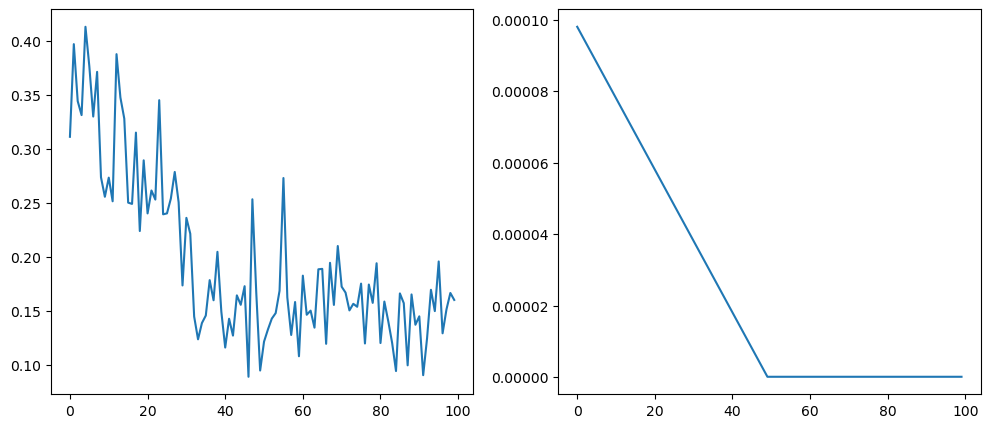

In [217]:
model = LinearSplinesNN(4, 64)
loss_fn = torch.nn.L1Loss()
loss, lrs = model.fit(X, y, loss_fn, n_epochs=100, lr=1e-4)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(loss)
ax[1].plot(lrs)

In [221]:
with torch.no_grad():

    fig, ax = plt.subplots()
    title = "Fitted Linear Spline"

    ax.set(title=title)
    ax.scatter(X[:,1], y)
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    x = torch.Tensor(np.linspace(*ax.get_xlim()))
    params = model.model(X[0,0].reshape(1,1)).T
    print(params)
    y_hat = model.linear_splines(x, *params)
    lines = ax.plot(x, y_hat)[0]
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    def update(frame):
        params = model.model(X[frame,0].reshape(1,1)).T
        y_hat = model.linear_splines(x, *params)
        lines.set_ydata(y_hat)
        ax.set(title=title + ". frame: " + str(frame))
        return lines

    ani = animation.FuncAnimation(fig=fig, func=update, frames=100, interval=60)
    ani.save(filename="linear_spline_over_time.gif", writer="pillow")
    plt.close(fig)


tensor([[-1.2711],
        [-1.2589],
        [ 0.1481],
        [-0.1235]])


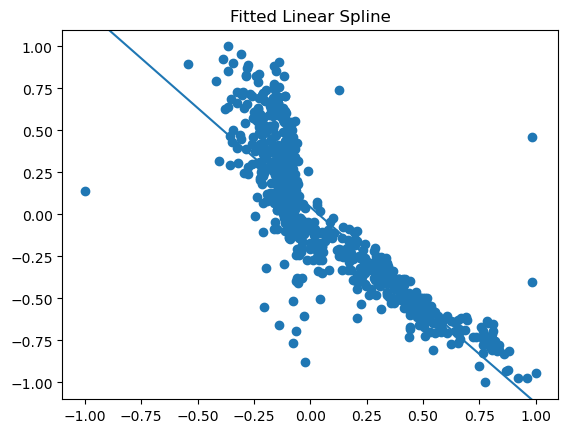

In [222]:
with torch.no_grad():
    fig, ax = plt.subplots()
    title = "Fitted Linear Spline"

    ax.set(title=title)
    ax.scatter(X[:,1], y)
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    x = torch.Tensor(np.linspace(*ax.get_xlim()))
    params = model.model(X[100,0].reshape(1,1)).T
    y_hat = model.linear_splines(x, *params)
    lines = ax.plot(x, y_hat)[0]
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

Learned fit: 0.04972582682967186
Manual fit: 0.09360449016094208


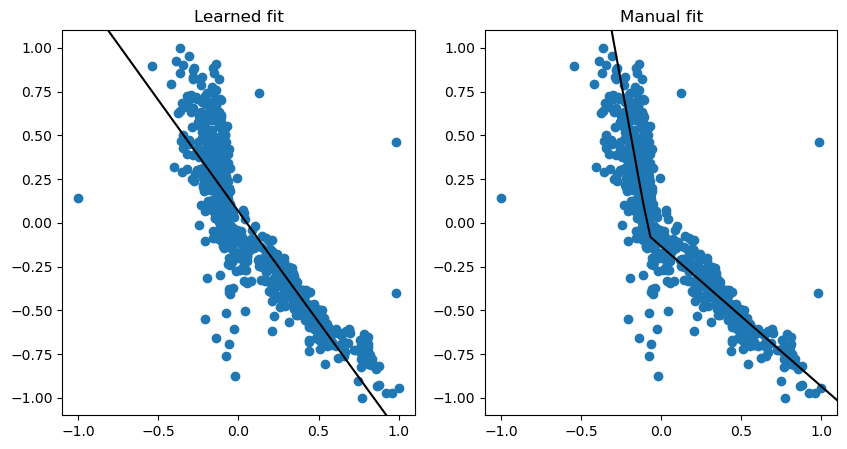

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].scatter(X[:,1], y)
ax[0].set_title("Learned fit")
x = np.linspace(*ax[0].get_xlim())
xlim = ax[0].get_xlim()
ylim = ax[0].get_ylim()

# params = [0.0080, -0.0091, -0.0031, 0.0967]
# params = np.array([[ 0.0038], [-0.0128], [ 0.0346], [ 0.4030]]).flatten()
params = np.array([[-1.2711], [-1.2589], [ 0.1481], [-0.1235]]).flatten()
y_hat = model.linear_splines(x, *params)
ax[0].plot(x, y_hat, c="black")

y_hat1 = model.linear_splines(X[:,1], *params).reshape(-1, 1)


ax[1].scatter(X[:,1], y)
ax[1].set_title("Manual fit")

params = [-5, -0.8, -0.075, -0.075]
y_hat = model.linear_splines(x, *params)
ax[1].plot(x, y_hat, c="black")


y_hat2 = model.linear_splines(X[:,1], *params).reshape(-1, 1)

ax[1].set_xlim(xlim)
ax[1].set_ylim(ylim)
ax[0].set_xlim(xlim)
ax[0].set_ylim(ylim)

# loss_fn = nn.L1Loss()
loss_fn = nn.MSELoss()
print(f"Learned fit: {loss_fn(y_hat1, y).item()}")
print(f"Manual fit: {loss_fn(y_hat2, y).item()}")

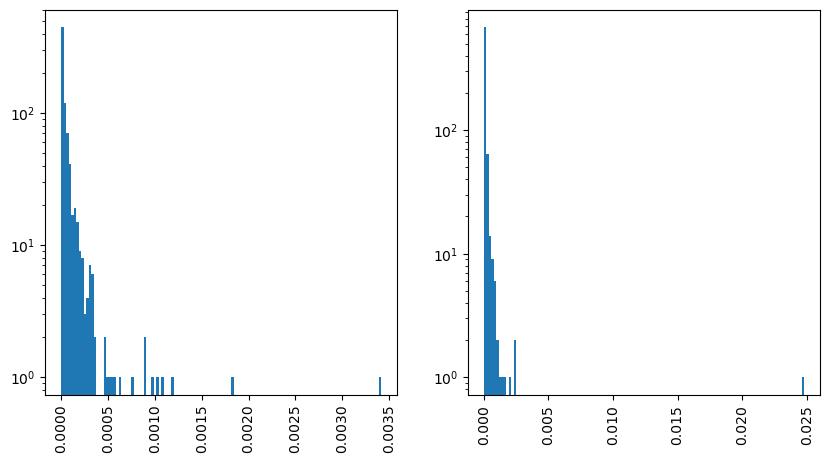

In [253]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
n_bins=128
mse1 = np.array((y_hat1 - y)**2 / len(y))
mse2 = np.array((y_hat2 - y)**2 / len(y))
ax[0].hist(mse1, bins=n_bins, log=True);
ax[1].hist(mse2, bins=n_bins, log=True);
ax[0].tick_params(axis='x', rotation=90)
ax[1].tick_params(axis='x', rotation=90)

57
Learned fit: 0.03238080069422722
Manual fit: 0.03355195000767708


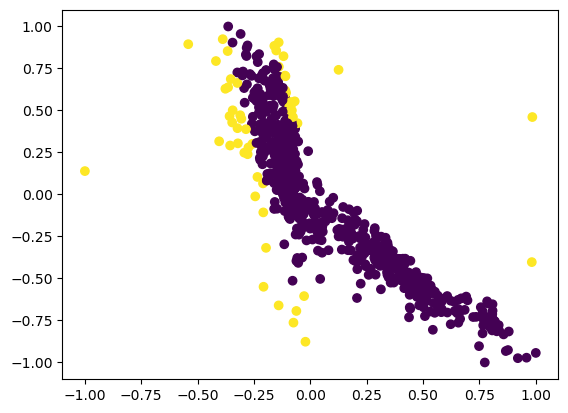

In [291]:
fig, ax = plt.subplots()

mask = mse2 < 0.0003
print((~mask).sum())
# y_np = y.numpy()
ax.scatter(X[:,1], y, c=~mask)
print(f"Learned fit: {loss_fn(y_hat1[mask], y[mask])}")
print(f"Manual fit: {loss_fn(y_hat2[mask], y[mask])}")